Perceptron algorithm in Python

The perceptron was one of the first neutral networks created. It is designed to be a binary classifier of linearly separable data.

Dataset:

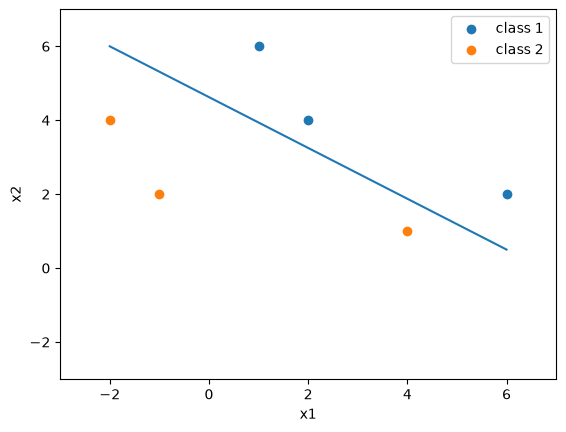

In [3]:
import numpy as np
import matplotlib.pyplot as plt

data = np.array([
    [-2,4,1],
    [4,1,1],
    [-1,2,1],
    [1, 6, 1],
    [2, 4, 1],
    [6, 2, 1],
])
label = np.array([-1,-1,-1,1,1,1])

class_pos = data[label == 1]
class_neg = data[label == -1]

#plot positive / class 1
x1 = class_pos[:,0]
x2 = class_pos[:,1]
plt.scatter(x1,x2, label = 'class 1')  

#plot negative / class 2
x1 = class_neg[:,0]
x2 = class_neg[:,1]
plt.scatter(x1,x2, label = 'class 2')

#possible hyperplane
plt.plot([-2, 6],[6, 0.5])

plt.xlabel('x1')
plt.ylabel('x2')
plt.xlim(-3, 7)
plt.ylim(-3, 7)
plt.legend()
plt.show()


The choosen separating hyperplane: w = (0.6875,1) b = -4.625 is a potential hyperplane; out of an infinite number of possible planes; that accurately separates the data into class1 and class2. The goal of the perceptron is to produce a hyperplane like this one using only the data and it's known class.

Part C
The theoredical bound for number of mistakes is significantly larger than the actual number of mistakes the algorithm made.
This means that the bound is not very tight

mistake:     [-2  6  1]
new weight:  [-2  6  1]


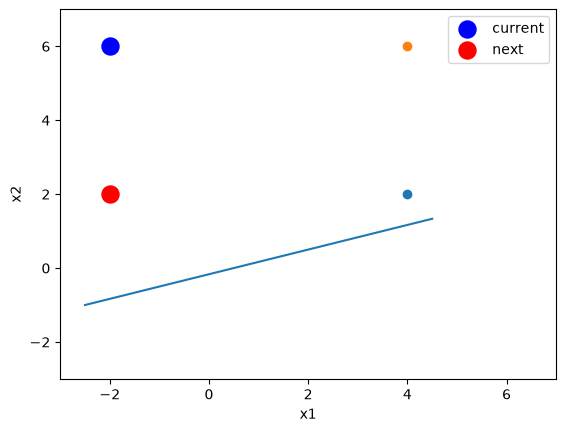

mistake:     [-2  2  1]
new weight:  [0 4 0]


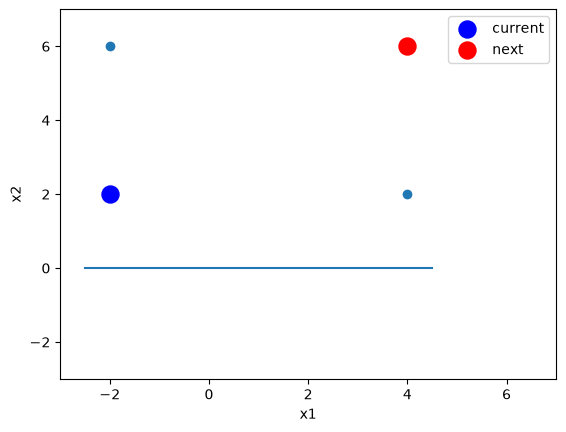

mistake:     [4 6 1]
new weight:  [-4 -2 -1]


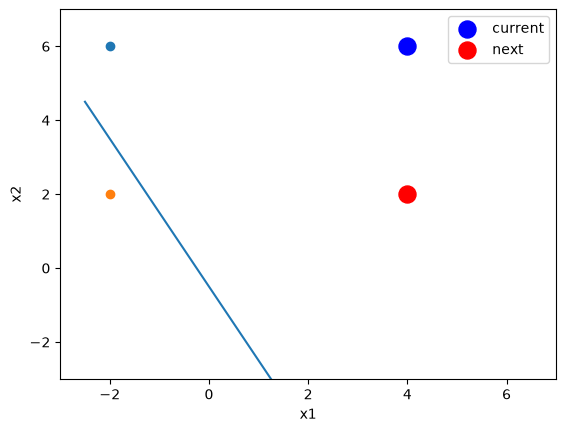

mistake:     [4 2 1]
new weight:  [0 0 0]


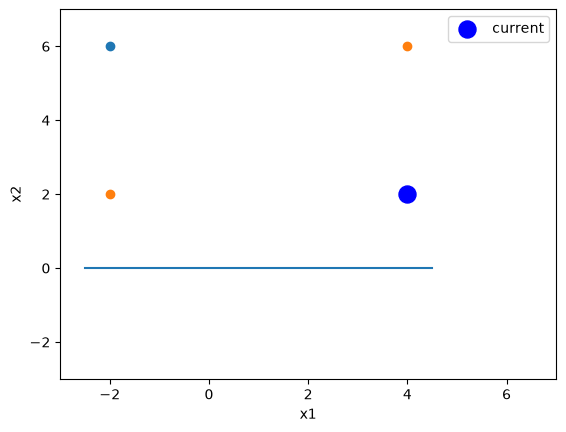

mistake:     [-2  6  1]
new weight:  [-2  6  1]


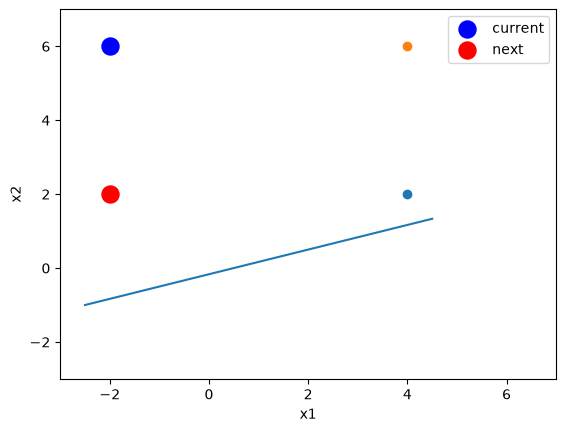

mistake:     [-2  2  1]
new weight:  [0 4 0]


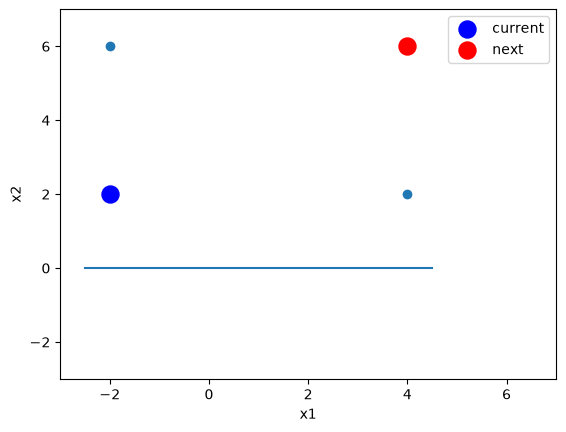

mistake:     [4 6 1]
new weight:  [-4 -2 -1]


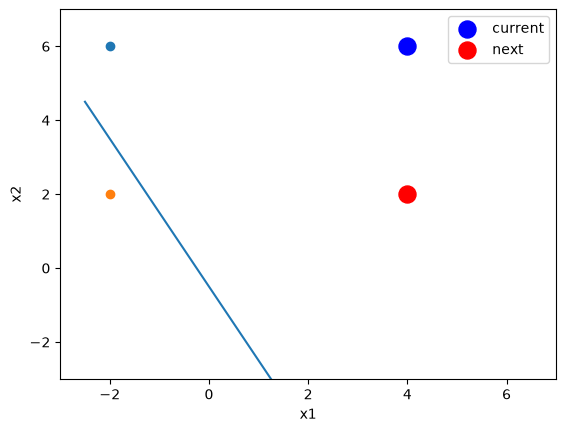

mistake:     [4 2 1]
new weight:  [0 0 0]


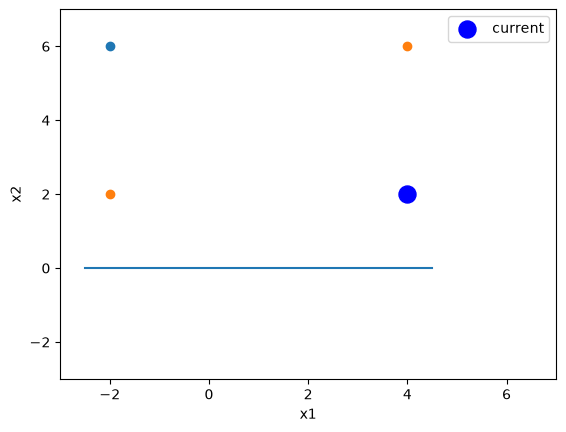

(array([0, 0, 0]), [4, 4])

In [5]:
import numpy as np
import matplotlib.pyplot as plt

XORdata = np.array([
    [-2,6,1],
    [-2,2,1],
    [4,6,1],
    [4,2,1]
])
XORlabel = np.array([1,-1,-1,1])

#perceptron algorithm + ploting 
def perceptron(data, label):

    #initialize weight and bias
    w = np.array([0,0,0])
    errors = []
    eta = 1

    #classify data
    class_pos = data[label == 1]
    class_neg = data[label == -1]

    #two passes through dataset
    for t in range(2):

        error = 0

        for i, (x,y) in enumerate(zip(data,label)):
            yi = np.dot(w,x)

            if yi > 0:
                prediction = 1
            else:
                prediction = -1

            if y != prediction:
                error += 1
                w = w + eta * y * x

                print("mistake:    ", x)
                print("new weight: ", w)

                #plot positive
                x1 = class_pos[:,0]
                x2 = class_pos[:,1]
                plt.scatter(x1,x2)  

                #plot negative
                x1 = class_neg[:,0]
                x2 = class_neg[:,1]
                plt.scatter(x1,x2)

                #plot current point 
                plt.scatter(x[0],x[1], s=150, color = 'blue', label= 'current')

                #plot next point 
                if i + 1 < len(data):
                    next_x = data[i+1]  
                    plt.scatter(next_x[0],next_x[1], s=150, color = 'red', label = 'next')

                #plot decision boundry
                xs = np.linspace(data[:,0].min()-0.5, data[:,0].max()+0.5, 200)
                ys = -(w[0]*xs + w[2]) / (w[1] + 1e-12)
                plt.plot(xs, ys)  

                #plot weight vector

                plt.xlabel('x1')
                plt.ylabel('x2')
                plt.xlim(-3, 7)
                plt.ylim(-3, 7)
                plt.legend()
                plt.show()

        errors.append(error)
            
        if error == 0:
            break 

    return w, errors

perceptron(XORdata, XORlabel)
